cluster-notebook.ipynb

## Steps

K-means 1: Create Cluster Pipeline 
- data cleaning 
- feature engineering
- feature scaling
- PCA
- KMeans Cluster Model

K-means 2: PCA components number?

K-means 3: Elbow Method and Silhouette score 
- define the number of clusters in Cluster Pipeline

K-means 4: Fit cluster pipeline

K-means 5: Add cluster predictions to data

K-means 6: Create Classifier Pipeline 
- separate pipeline where the target variable is cluster predictions and features are the remaining variables

K-means 7: Fit classifier
- evaluate its performance and assess the most important features

K-means 8: Cluster analysis
- explain each cluster profile in terms of the most important features


In [1]:
# import required libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("C:\\Users\\beth_\\Documents\\health-insurance\\health-insurance-project-1\\Iris-Clustering\\data\\data_clean.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


The Code Institute notebook I am referring to during this algorithm uses the Iris dataset directly from sklearn. 
Therefore I will adapt the kaggle data to behave like the sklearn dataset: with attributes (features names and target).

In [3]:
X = df.drop("Species", axis=1)   # features
y = df["Species"]                # target

In [4]:
feature_names = X.columns.tolist()
data_array = X.values
target = y.values

In [5]:
# chatgpt suggested using a Bunch object to store the data, feature names, and target. 
# This is a common practice in machine learning projects to keep the data organized and easily accessible.

class Bunch:
    def __init__(self, data, feature_names, target):
        self.data = data
        self.feature_names = feature_names
        self.target = target

data = Bunch(data_array, feature_names, target)

In [6]:
df2 = pd.DataFrame(data.data, columns=data.feature_names)
df2.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,1.0,5.1,3.5,1.4,0.2
1,2.0,4.9,3.0,1.4,0.2
2,3.0,4.7,3.2,1.3,0.2
3,4.0,4.6,3.1,1.5,0.2
4,5.0,5.0,3.6,1.4,0.2


In [7]:
from sklearn.preprocessing import LabelEncoder

# encode the target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)

Now we are ready to start work on the pipeline. Remembering to use
- df2
- x
- y_encoded

Step 1: create ML cluster pipeline

In [8]:
from sklearn.pipeline import Pipeline

# Data Cleaning
from feature_engine.imputation import MeanMedianImputer

# Feat Scaling
from sklearn.preprocessing import StandardScaler

# PCA
from sklearn.decomposition import PCA

# ML algorithm
from sklearn.cluster import KMeans

# create pipeline
# the values of n_components and n_clusters are arbitrary, we will find the optimal values in the next steps

def PipelineCluster():
  pipeline_base = Pipeline([
                            
      ( 'MeanMedianImputer', MeanMedianImputer(imputation_method='median') ),

      ("scaler", StandardScaler()  ),    

      ("PCA",  PCA(n_components=20, random_state=0)), 

      ("model", KMeans(n_clusters=20, random_state=0)  ), 
  ])
  return pipeline_base

PipelineCluster()

Pipeline(steps=[('MeanMedianImputer', MeanMedianImputer()),
                ('scaler', StandardScaler()),
                ('PCA', PCA(n_components=20, random_state=0)),
                ('model', KMeans(n_clusters=20, random_state=0))])

Principal Component Analysis

PCA transforms the data and tries to determine what features explain the most variance.

After the transformation, it creates a set of components (less than the number of variables), where each component contains the relevant information from the original variables.

The optimum number of n_components needs to be found as this will impact the algorithm's performance. 

In [9]:
pipeline_cluster = PipelineCluster()
pipeline_pca = Pipeline(pipeline_cluster.steps[:-2])
df_pca = pipeline_pca.fit_transform(df2)

print(df_pca.shape,'\n', type(df_pca))

(150, 5) 
 <class 'numpy.ndarray'>


In [10]:
n_components = 5 # set the number of components as all columns in the data

pca = PCA(n_components=n_components).fit(df_pca)  # set PCA object and fit to the data
x_PCA = pca.transform(df_pca) # array with transformed PCA


# the PCA object has .explained_variance_ratio_ attribute, which tells 
# how much information (variance) each component has 

# we store that to a DataFrame relating each component to its variance explanation
ComponentsList = ["Component " + str(number) for number in range(n_components)]
dfExplVarRatio = pd.DataFrame(
    data= np.round(100 * pca.explained_variance_ratio_ ,3),
    index=ComponentsList,
    columns=['Explained Variance Ratio (%)'])

# print how much of the dataset these components explain
PercentageOfData = dfExplVarRatio['Explained Variance Ratio (%)'].sum()

print(f"* The {n_components} components explain {round(PercentageOfData,2)}% of the data \n")
print(dfExplVarRatio)

* The 5 components explain 100.0% of the data 

             Explained Variance Ratio (%)
Component 0                        74.705
Component 1                        18.435
Component 2                         4.683
Component 3                         1.765
Component 4                         0.412


Great! 5 components explain 100.0% of the data. 

If there were a greater number columns in the data and therefore a greater number of components we would choose n where the total explained variance ratio was over 90%.

In [11]:
def PipelineCluster():
  pipeline_base = Pipeline([
                            
      ( 'MeanMedianImputer', MeanMedianImputer(imputation_method='median') ),

      ("scaler", StandardScaler()  ),    

      ("PCA",  PCA(n_components=5, random_state=0)),  ##### we update the n_components to 5

      ("model", KMeans(n_clusters=30, random_state=0)  ), 
  ])
  return pipeline_base

PipelineCluster()

Pipeline(steps=[('MeanMedianImputer', MeanMedianImputer()),
                ('scaler', StandardScaler()),
                ('PCA', PCA(n_components=5, random_state=0)),
                ('model', KMeans(n_clusters=30, random_state=0))])

Elbow method and silhouette score: use these two methods to find the optimum number of clusters (we expect there to be three clusters as there are three types of iris in the data).

In [12]:
pipeline_cluster = PipelineCluster()
pipeline_analysis = Pipeline(pipeline_cluster.steps[:-1])
df_analysis = pipeline_analysis.fit_transform(df2)

print(df_analysis.shape,'\n', type(df_analysis))

(150, 5) 
 <class 'numpy.ndarray'>


c:\Users\beth_\Documents\health-insurance\health-insurance-project-1\Iris-Clustering\.venv\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\beth_\Documents\health-insurance\health-insurance-project-1\Iris-Clustering\.venv\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\beth_\Documents\health-insurance\health-insurance-project-1\Iris-Clustering\.venv\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input

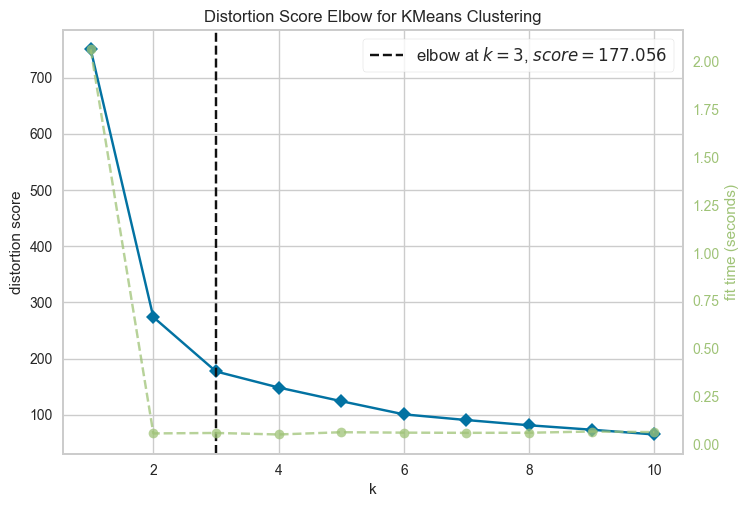

In [ ]:
# install setuptools to configure yellowbrick (future warnings)
from yellowbrick.cluster import KElbowVisualizer

# using the k-means algorithm, we will find the optimal number of clusters for our data using the elbow method.
visualizer = KElbowVisualizer(KMeans(random_state=0), k=(1,11))
visualizer.fit(df_analysis) 
visualizer.show() 
plt.show()

The Elbow Method suggests that 3 is the optimal numbers of clusters.